--- Анализ файла: data_idxs_for_debug.npy ---
Форма массива (количество строк/признаков): (14, 10018)

# Статистика для Строки 0:
  Min: 47.0000
  Max: 65.0000
  Mean: 56.0393
  Std Dev: 5.3212

# Статистика для Строки 1:
  Min: 47.0000
  Max: 83.0000
  Mean: 65.6004
  Std Dev: 11.5125

# Статистика для Строки 2:
  Min: 15.0000
  Max: 758.0000
  Mean: 389.6707
  Std Dev: 213.4168

# Статистика для Строки 3:
  Min: 0.0863
  Max: 1.0877
  Mean: 0.5832
  Std Dev: 0.2906

# Статистика для Строки 4:
  Min: 0.0833
  Max: 1.0000
  Mean: 0.5385
  Std Dev: 0.2886

# Статистика для Строки 5:
  Min: 0.3427
  Max: 0.5670
  Mean: 0.4553
  Std Dev: 0.0663

# Статистика для Строки 6:
  Min: 0.0000
  Max: 0.2250
  Mean: 0.1163
  Std Dev: 0.0720

============--- ТАРГЕТЫ 'y' НАЧИНАЮТСЯ ЗДЕСЬ ---============

# Статистика для Строки 7:
  Min: 0.9774
  Max: 32.0352
  Mean: 11.5736
  Std Dev: 4.9048

# Статистика для Строки 8:
  Min: 0.9774
  Max: 25.0275
  Mean: 7.9739
  Std Dev: 3.4308

# Статистика для 

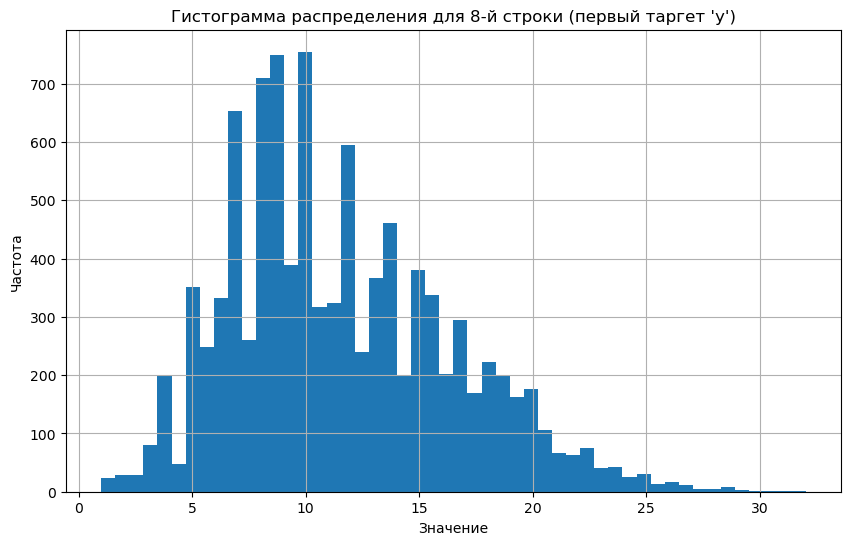

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Настройки ---
# Убедись, что путь к файлу правильный
file_path = 'data_idxs_for_debug.npy' 
# -----------------

# Включаем отображение графиков прямо в ноутбуке
%matplotlib inline

try:
    # Загружаем массив из файла
    data_column = np.load(file_path)
    
    print(f"--- Анализ файла: {file_path} ---")
    print(f"Форма массива (количество строк/признаков): {data_column.shape}")
    print("="*60)

    # Проходимся по каждой строке массива
    for i in range(data_column.shape[0]):
        row_data = data_column[i]
        
        # Ставим разделитель перед 8-й строкой (индекс 7), где начинаются таргеты 'y'
        if i == 7:
            print("\n" + "--- ТАРГЕТЫ 'y' НАЧИНАЮТСЯ ЗДЕСЬ ---".center(60, "="))

        # Считаем и выводим статистику для текущей строки
        print(f"\n# Статистика для Строки {i}:")
        print(f"  Min: {np.min(row_data):.4f}")
        print(f"  Max: {np.max(row_data):.4f}")
        print(f"  Mean: {np.mean(row_data):.4f}")
        print(f"  Std Dev: {np.std(row_data):.4f}")

    # Визуализируем распределение для первой таргетной переменной (8-я строка)
    if data_column.shape[0] > 7:
        plt.figure(figsize=(10, 6))
        plt.hist(data_column[7], bins=50)
        plt.title("Гистограмма распределения для 8-й строки (первый таргет 'y')")
        plt.xlabel("Значение")
        plt.ylabel("Частота")
        plt.grid(True)
        plt.show()

except FileNotFoundError:
    print(f"Ошибка: Файл '{file_path}' не найден. Проверь путь и имя файла.")
except Exception as e:
    print(f"Произошла ошибка: {e}")

In [5]:
data_column

array([[ 54.       ,  54.       ,  54.       , ...,  52.       ,
         52.       ,  52.       ],
       [ 65.       ,  65.       ,  65.       , ...,  65.       ,
         65.       ,  65.       ],
       [ 15.       ,  29.       ,  43.       , ..., 729.       ,
        743.       , 757.       ],
       ...,
       [  4.256991 ,   4.990068 ,   4.012632 , ...,   2.623644 ,
          2.739393 ,   3.21525  ],
       [  3.34386  ,   4.012632 ,   4.012632 , ...,   2.623644 ,
          2.623644 ,   2.623644 ],
       [  2.006316 ,   2.4461622,   2.4461622, ...,   1.491876 ,
          2.0011716,   2.623644 ]])

In [7]:
import pandas as pd

path = "data/cmip5_world/target.parquet"

# Load (requires either 'pyarrow' or 'fastparquet')
df = pd.read_parquet(path, engine="fastparquet")  # or engine="fastparquet"

# Optional: better display in notebooks
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Quick look
print("Shape:", df.shape)
display(df.head(10))  # if not in a notebook, use: print(df.head(10))
print("\nDtypes:\n", df.dtypes)

Shape: (15930329, 6)


,time,station_name,y,lat,lon,height
0,2006-02-02,тегюлтя,1.0,59.99952,0.0,173.0
1,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
2,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
3,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
4,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
5,2006-02-02,тегюлтя,3.0,59.99952,0.0,173.0
6,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
7,2006-02-02,тегюлтя,4.0,59.99952,0.0,173.0
8,2006-02-03,тегюлтя,5.0,59.99952,0.0,173.0
9,2006-02-03,тегюлтя,4.0,59.99952,0.0,173.0



Dtypes:
 time            datetime64[ns]
station_name            object
y                      float64
lat                    float64
lon                    float64
height                 float64
dtype: object


In [8]:
df[df['y']>30]

,time,station_name,y,lat,lon,height
70324,2006-02-27,терней,32.000000,45.42028,0.00,51.0
70325,2006-02-27,терней,31.000000,45.42028,0.00,51.0
72469,2006-11-22,терней,33.000000,45.42028,0.00,51.0
72470,2006-11-22,терней,34.000000,45.42028,0.00,51.0
72472,2006-11-22,терней,39.000000,45.42028,0.00,51.0
...,...,...,...,...,...,...
15915713,2009-06-25,88963099999,33.387156,-63.36393,146.25,NaN
15915714,2009-06-26,88963099999,30.763512,-63.36393,146.25,NaN
15915724,2009-07-06,88963099999,30.763512,-63.36393,146.25,NaN
15915781,2009-09-01,88963099999,30.763512,-63.36393,146.25,NaN


# Open .nc

In [4]:
import xarray as xr
import pandas as pd
import numpy as np

path = "data/cmip5_world_orig/sfcWindmax_day_cmip5_cmip5world_r1i1p1_1950-01-01-2020-11-13.nc"
ds = xr.open_dataset(path)

# Посмотри имена координат и переменной
print(ds)

<xarray.Dataset>
Dimensions:     (time: 25867, lat: 115, lon: 161)
Coordinates:
  * time        (time) datetime64[ns] 1950-01-01T12:00:00 ... 2020-11-13T12:0...
  * lon         (lon) float64 0.0 1.125 2.25 3.375 ... 176.6 177.8 178.9 180.0
  * lat         (lat) float64 -47.66 -46.54 -45.42 -44.3 ... 77.94 79.06 80.19
Data variables:
    sfcWindmax  (time, lat, lon) float32 ...


In [2]:
ds.data_vars

Data variables:
    sfcWindmax  (time, lat, lon) float32 ...

In [10]:
var_name = 'sfcWindmax'
da = ds[var_name]
da_test = da.sel(time=slice("2017-01-01", "2020-12-31"))

In [7]:
display(da_test)

<xarray.DataArray 'sfcWindmax' (time: 682, lat: 115, lon: 161)>
[12627230 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 2019-01-01T12:00:00 ... 2020-11-13T12:00:00
  * lon      (lon) float64 0.0 1.125 2.25 3.375 4.5 ... 176.6 177.8 178.9 180.0
  * lat      (lat) float64 -47.66 -46.54 -45.42 -44.3 ... 77.94 79.06 80.19
Attributes:
    standard_name:     wind_speed
    long_name:         Daily Maximum Near-Surface Wind Speed
    units:             m s-1
    original_name:     WIND
    cell_methods:      time: maximum (interval: 30 minutes)
    history:           2011-05-02T09:49:44Z altered by CMOR: Treated scalar d...
    associated_files:  baseURL: http://cmip-pcmdi.llnl.gov/CMIP5/dataLocation...

In [12]:
import numpy as np
da_test.isnull().mean().item()

0.0

In [16]:
import polars as pl
df_obs = pl.read_parquet("data/weatherstation_data/df_obs.parquet")
print(df_obs.schema, df_obs.height)


Schema([('STATION', Int64), ('DATE', Date), ('LATITUDE', Float64), ('LONGITUDE', Float64), ('MXSPD', Float64), ('y_true', Int8)]) 2454571


# Привести станционные координаты к координатной сетке CMIP. Также для каждой станции в каждый день получить значение из ЦМИП. Результат - data/weatherstation_data/cmip_station_daily_2017_2020-11-13.parquet

In [1]:
import polars as pl
import xarray as xr
import pandas as pd
import numpy as np
from datetime import date

In [2]:
# === пути (ПОМЕНЯЙ под себя) ===
STATIONS_PATH = "data/weatherstation_data/stations.parquet"
CMIP_PATH = "data/cmip5_world_orig/sfcWindmax_day_cmip5_cmip5world_r1i1p1_1950-01-01-2020-11-13.nc"
OUT_PATH = "data/weatherstation_data/cmip_station_daily_2017_2020-11-13.parquet"

# === 1) читаем станции ===
stations = pl.read_parquet(STATIONS_PATH)

# sanity-check
assert set(stations.columns) >= {"STATION", "LATITUDE", "LONGITUDE"}
print("stations:", stations.height)
print(stations.head())

# === 2) открываем CMIP и режем по времени ===
ds = xr.open_dataset(CMIP_PATH)
da = ds["sfcWindmax"].sel(time=slice("2017-01-01", "2020-11-13"))

# приводим время к date (без времени)
times = pd.to_datetime(da["time"].values).date
n_time = len(times)
print("cmip time points:", n_time, "from", times[0], "to", times[-1])

# координаты сетки (монотонные 1D)
lat_grid = da["lat"].values
lon_grid = da["lon"].values

# === 3) функция поиска ближайшего индекса на монотонной сетке ===
def nearest_index(grid: np.ndarray, x: float) -> int:
    # grid должен быть отсортирован по возрастанию
    i = int(np.searchsorted(grid, x))
    if i <= 0:
        return 0
    if i >= len(grid):
        return len(grid) - 1
    # выбираем ближнюю из двух соседних
    return i if abs(grid[i] - x) < abs(grid[i-1] - x) else i-1

# === 4) извлечение рядов по станциям ===
st_pdf = stations.to_pandas()
rows = []

# загрузим da в память "лениво" не получится; но time×lat×lon ~ 12.6 млн float32
# это ~50 МБ, обычно ок. Чтобы ускорить выборки по точкам, можно загрузить в numpy:
da_np = da.values  # shape: (time, lat, lon), dtype float32

for r in st_pdf.itertuples(index=False):
    st = int(r.STATION)
    lat = float(r.LATITUDE)
    lon = float(r.LONGITUDE)

    # твой lon уже 0..180, но на всякий случай проверим
    if lon < float(lon_grid.min()) or lon > float(lon_grid.max()):
        continue

    ilat = nearest_index(lat_grid, lat)
    ilon = nearest_index(lon_grid, lon)

    series = da_np[:, ilat, ilon]  # shape (time,)

    # добавляем в список как 3 колонки
    rows.append(
        pd.DataFrame({
            "STATION": st,
            "DATE": times,
            "cmip_wind": series.astype(np.float32),
        })
    )

cmip_df = pd.concat(rows, ignore_index=True)

# === 5) сохраняем ===
cmip_pl = pl.from_pandas(cmip_df).with_columns(
    pl.col("DATE").cast(pl.Date)
)

cmip_pl.write_parquet(OUT_PATH, compression="zstd", statistics=True)

print("saved:", OUT_PATH, "rows:", cmip_pl.height, "stations:", cmip_pl.select(pl.col("STATION").n_unique()).item())
print(cmip_pl.head())


stations: 2066
shape: (5, 3)
┌────────────┬───────────┬───────────┐
│ STATION    ┆ LATITUDE  ┆ LONGITUDE │
│ ---        ┆ ---       ┆ ---       │
│ i64        ┆ f64       ┆ f64       │
╞════════════╪═══════════╪═══════════╡
│ 1006099999 ┆ 78.25     ┆ 22.816667 │
│ 1009099999 ┆ 80.65     ┆ 25.0      │
│ 1011099999 ┆ 80.066667 ┆ 31.5      │
│ 1016099999 ┆ 78.933333 ┆ 28.9      │
│ 1028099999 ┆ 74.516667 ┆ 19.016667 │
└────────────┴───────────┴───────────┘
cmip time points: 1412 from 2017-01-01 to 2020-11-13
saved: data/weatherstation_data/cmip_station_daily_2017_2020-11-13.parquet rows: 2917192 stations: 2066
shape: (5, 3)
┌────────────┬────────────┬───────────┐
│ STATION    ┆ DATE       ┆ cmip_wind │
│ ---        ┆ ---        ┆ ---       │
│ i64        ┆ date       ┆ f32       │
╞════════════╪════════════╪═══════════╡
│ 1006099999 ┆ 2017-01-01 ┆ 6.049368  │
│ 1006099999 ┆ 2017-01-02 ┆ 5.827217  │
│ 1006099999 ┆ 2017-01-03 ┆ 10.758023 │
│ 1006099999 ┆ 2017-01-04 ┆ 13.296952 │
│ 100609999

In [4]:
cmip_pl

STATION,DATE,cmip_wind
i64,date,f32
1006099999,2017-01-01,6.049368
1006099999,2017-01-02,5.827217
1006099999,2017-01-03,10.758023
1006099999,2017-01-04,13.296952
1006099999,2017-01-05,13.358968
…,…,…
99999900472,2020-11-09,4.500803
99999900472,2020-11-10,4.189319
99999900472,2020-11-11,5.430988


Join df_obs ↔ cmip_station_daily

In [ ]:
import polars as pl
from datetime import date
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

DF_OBS_PATH   = "data/weatherstation_data/df_obs_2000_2020_Russia.parquet"
CMIP_ST_PATH  = "data/weatherstation_data/cmip_station_2000_2020_Russia.parquet"

df_obs  = pl.read_parquet(DF_OBS_PATH)
cmip_st = pl.read_parquet(CMIP_ST_PATH)

# inner join по (STATION, DATE)
df_eval = df_obs.join(cmip_st, on=["STATION", "DATE"], how="inner")

print("df_obs rows:", df_obs.height)
print("cmip_st rows:", cmip_st.height)
print("df_eval rows:", df_eval.height)
print("coverage:", df_eval.height / df_obs.height)

df_obs rows: 10879957
cmip_st rows: 18425523
df_eval rows: 10871217
coverage: 0.9991966880016162


Разделение на val / test

In [10]:
df_val = df_eval.filter(
    pl.col("DATE").is_between(date(2017,1,1), date(2018,12,31))
)

df_test = df_eval.filter(
    pl.col("DATE").is_between(date(2019,1,1), date(2020,11,13))
)

print(
    "val:", df_val.height, 
    "events:", df_val.select(pl.col("y_true").sum()).item(),
    "rate:", df_val.select(pl.col("y_true").mean()).item()
)
print(
    "test:", df_test.height, 
    "events:", df_test.select(pl.col("y_true").sum()).item(),
    "rate:", df_test.select(pl.col("y_true").mean()).item()
)


val: 1260954 events: 71345 rate: 0.05658017659644999
test: 1191781 events: 71088 rate: 0.05964854281113728


### Baseline “CMIP threshold”

- на val подбираем порог T для cmip_wind,

- фиксируем его,

- считаем метрики только на test.

In [11]:
x_val = df_val["cmip_wind"].to_numpy()
y_val = df_val["y_true"].to_numpy()

x_test = df_test["cmip_wind"].to_numpy()
y_test = df_test["y_true"].to_numpy()


Подбор порога

Берём квантили — этого достаточно для baseline.

In [13]:
candidates = np.quantile(x_val, np.linspace(0.80, 0.999, 200))

best_T = None
best_f1 = -1.0

for T in candidates:
    y_pred = (x_val > T).astype(int)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_T = T

best_T, best_f1
# 2 mins


(9.50539086341858, 0.1947260080192775)

Метрики baseline на test (главное для статьи)

Это основной baseline, с которым будем сравнивать CNN.

In [15]:
y_pred_test = (x_test > best_T).astype(int)

precision = precision_score(y_test, y_pred_test, zero_division=0)
recall    = recall_score(y_test, y_pred_test, zero_division=0)
f1        = f1_score(y_test, y_pred_test, zero_division=0)

precision, recall, f1


(0.14645999952815722, 0.26198514517218097, 0.18788493258477973)

# Проверка правильности станционных данных, подготовленных на локальной машине: data/weatherstation_data/stations.parquet и df_obs.parquet

In [6]:

STATIONS_PATH = "data/weatherstation_data/stations.parquet"
CMIP_PATH = "data/cmip5_world_orig/sfcWindmax_day_cmip5_cmip5world_r1i1p1_1950-01-01-2020-11-13.nc"
CMIP_STATION_PATH = "data/weatherstation_data/cmip_station_daily_2017_2020-11-13.parquet"

stations = pl.read_parquet(STATIONS_PATH)
cmip_st = pl.read_parquet(CMIP_STATION_PATH)

n_st = stations.height
n_days = (
    cmip_st.select(pl.col("DATE").n_unique()).item()
)
print("stations:", n_st)
print("unique days in cmip_st:", n_days)
print("rows cmip_st:", cmip_st.height, "expected ~", n_st * n_days)


stations: 2066
unique days in cmip_st: 1412
rows cmip_st: 2917192 expected ~ 2917192


In [7]:
# 10 случайных станций
sample_st = (
    stations
    .select(["STATION", "LATITUDE", "LONGITUDE"])
    .sample(10, seed=42)
)

# откроем CMIP
ds = xr.open_dataset(CMIP_PATH)
da = ds["sfcWindmax"].sel(time=slice("2017-01-01", "2020-11-13"))

lat_grid = da["lat"].values
lon_grid = da["lon"].values

def nearest_index(grid: np.ndarray, x: float) -> int:
    i = int(np.searchsorted(grid, x))
    if i <= 0:
        return 0
    if i >= len(grid):
        return len(grid) - 1
    return i if abs(grid[i] - x) < abs(grid[i-1] - x) else i-1

# выберем 3 даты для проверки
check_dates = [date(2019,1,1), date(2020,6,15), date(2020,11,13)]

cmip_st_lf = pl.scan_parquet(CMIP_STATION_PATH)

for row in sample_st.iter_rows(named=True):
    st = row["STATION"]
    lat = float(row["LATITUDE"])
    lon = float(row["LONGITUDE"])

    ilat = nearest_index(lat_grid, lat)
    ilon = nearest_index(lon_grid, lon)
    lat_nn = float(lat_grid[ilat])
    lon_nn = float(lon_grid[ilon])

    print("\nSTATION:", st, "station(lat,lon)=", (lat, lon), "nearest_grid(lat,lon)=", (lat_nn, lon_nn))

    # значения из нашего parquet
    vals_parquet = (
        cmip_st_lf
        .filter((pl.col("STATION") == st) & (pl.col("DATE").is_in(check_dates)))
        .select(["DATE", "cmip_wind"])
        .collect()
        .sort("DATE")
    )

    # значения напрямую из xarray
    vals_xr = []
    for d in check_dates:
        v = da.sel(time=str(d), lat=lat, lon=lon, method="nearest").values.item()
        vals_xr.append(v)

    print("parquet:")
    print(vals_parquet)

    print("xarray :", list(zip(check_dates, vals_xr)))



STATION: 35563099999 station(lat,lon)= (48.583, 67.083) nearest_grid(lat,lon)= (48.78473, 67.5)
parquet:
shape: (3, 2)
┌────────────┬───────────┐
│ DATE       ┆ cmip_wind │
│ ---        ┆ ---       │
│ date       ┆ f32       │
╞════════════╪═══════════╡
│ 2019-01-01 ┆ 4.265909  │
│ 2020-06-15 ┆ 5.300139  │
│ 2020-11-13 ┆ 6.277802  │
└────────────┴───────────┘
xarray : [(datetime.date(2019, 1, 1), 4.265909194946289), (datetime.date(2020, 6, 15), 5.3001389503479), (datetime.date(2020, 11, 13), 6.277801513671875)]

STATION: 22717099999 station(lat,lon)= (62.1, 32.3833333) nearest_grid(lat,lon)= (62.24246, 32.625)
parquet:
shape: (3, 2)
┌────────────┬───────────┐
│ DATE       ┆ cmip_wind │
│ ---        ┆ ---       │
│ date       ┆ f32       │
╞════════════╪═══════════╡
│ 2019-01-01 ┆ 4.797885  │
│ 2020-06-15 ┆ 1.750136  │
│ 2020-11-13 ┆ 2.629166  │
└────────────┴───────────┘
xarray : [(datetime.date(2019, 1, 1), 4.797885417938232), (datetime.date(2020, 6, 15), 1.750135898590088), (datetim

In [8]:
df_obs = pl.read_parquet("data/weatherstation_data/df_obs.parquet")  # подставь путь

df_eval = df_obs.join(cmip_st, on=["STATION","DATE"], how="inner")

print("df_obs rows:", df_obs.height)
print("cmip_st rows:", cmip_st.height)
print("df_eval rows (inner join):", df_eval.height)
print("join coverage:", df_eval.height / df_obs.height)


df_obs rows: 2454571
cmip_st rows: 2917192
df_eval rows (inner join): 2452735
join coverage: 0.9992520077846597


Check difference

In [ ]:
from datetime import date
import polars as pl

# старый df_eval (строился с cmip_2017_2020)
# новый df_eval_new (строится с cmip_all)
# df_eval_new = 

d1, d2 = date(2017,1,1), date(2020,11,13)

old = df_eval.filter(pl.col("DATE").is_between(d1, d2)).sort(["STATION","DATE"])
new = df_eval_new.filter(pl.col("DATE").is_between(d1, d2)).sort(["STATION","DATE"])

# 1) одинаковое число строк
assert old.height == new.height

# 2) одинаковые значения cmip_wind и y_true на тех же ключах
# сравним через join и максимум абсолютной разницы
diff = (
    old.select(["STATION","DATE","cmip_wind","y_true"])
    .join(
        new.select(["STATION","DATE","cmip_wind","y_true"]),
        on=["STATION","DATE"],
        how="inner",
        suffix="_new"
    )
    .with_columns([
        (pl.col("cmip_wind") - pl.col("cmip_wind_new")).abs().alias("abs_diff")
    ])
)

assert diff.height == old.height  # все ключи совпали
max_diff = diff.select(pl.col("abs_diff").max()).item()
n_mismatch = diff.filter(pl.col("abs_diff") > 1e-6).height

print("max_abs_diff(cmip_wind):", max_diff)
print("n_mismatch(>1e-6):", n_mismatch)


max_abs_diff(cmip_wind): 0.0
n_mismatch(>1e-6): 0
